**Current Accounts Prediction Model**

*Objective*

This notebook predicts monthly UK Current Account balances using macroeconomic indicators (Bank Rate, CPI, GDP Growth and Unemployment Rate) alongside lagged Current Account values.

**Import Libraries**

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

**Load the Dataset**

In [69]:
df = pd.read_csv("FINAL_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,101598,54232
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211


**Feature Engineering**

In [70]:
# Current Accounts lag
df["Current_Accounts_Lag1"] = (
    df["Current_Accounts"].shift(1)
)


# Remove missing lag observations
df_model = (
    df
    .dropna()
    .reset_index(drop=True)
)

df_model.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,Current_Accounts_Lag1
0,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375,33417.0
1,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471,31492.0
2,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404,32823.0
3,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211,31895.0
4,2008-06-01,2008,June,5.00,3.8,5.5,64.2,-0.5,33348,241184,35391,100691,54955,32210.0


**Feature Selection**

In [71]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Current_Accounts_Lag1",

]

X = df_model[features]

y = df_model["Current_Accounts"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (215, 5)
y shape: (215,)


**Correlation Analysis**

In [72]:
# Correlation matrix
corr_matrix = df_model[
    features + ["Current_Accounts"]
].corr()

# Display correlation with the target variable
current_accounts_corr = corr_matrix["Current_Accounts"].sort_values(ascending=False)

current_accounts_corr

Current_Accounts         1.000000
Current_Accounts_Lag1    0.997961
Bank_Rate                0.440564
CPI                      0.346621
GDP_Growth               0.076289
Unemployment_Rate       -0.711060
Name: Current_Accounts, dtype: float64

**Multicollinearity Analysis (VIF)**

In [73]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
4,Current_Accounts_Lag1,4.630986
1,CPI,3.337128
3,Unemployment_Rate,2.987395
0,Bank_Rate,2.257527
2,GDP_Growth,1.029045


**STANDARDIZATION**

In [74]:
# StandardScaler

scaler = StandardScaler()

print(
    "StandardScaler created."
)

StandardScaler created.


**Walk-Forward Setup**

In [75]:
initial_train_size = int(
    len(df_model) * 0.70
)

print(
    "Total observations:",
    len(df_model)
)

print(
    "Initial training observations:",
    initial_train_size
)

print(
    "Walk-forward test observations:",
    len(df_model) - initial_train_size
)

Total observations: 215
Initial training observations: 150
Walk-forward test observations: 65


**Create Walk-Forward Storage**


In [76]:
lr_predictions = []
lr_actuals = []
lr_dates = []

rf_predictions = []
rf_actuals = []
rf_dates = []

xgb_predictions = []
xgb_actuals = []
xgb_dates = []

**Linear Regression Walk-Forward**

In [77]:
for i in range(
    initial_train_size,
    len(df_model)
):

    # -----------------------------
    # Historical training data
    # -----------------------------

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    # -----------------------------
    # Next unseen observation
    # -----------------------------

    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    # -----------------------------
    # Standardization
    # IMPORTANT:
    # fit ONLY on historical data
    # -----------------------------

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test
        )
    )

    # -----------------------------
    # Linear Regression
    # -----------------------------

    lr_model = LinearRegression()

    lr_model.fit(
        X_train_scaled,
        y_train
    )

    # -----------------------------
    # Prediction
    # -----------------------------

    prediction = lr_model.predict(
        X_test_scaled
    )[0]

    # -----------------------------
    # Store
    # -----------------------------

    lr_predictions.append(
        prediction
    )

    lr_actuals.append(
        y_test
    )

    lr_dates.append(
        df_model.iloc[i]["Date"]
    )

print(
    "Linear Regression walk-forward completed."
)

Linear Regression walk-forward completed.


**Linear Regression Evaluation**

In [78]:
lr_r2 = r2_score(
    lr_actuals,
    lr_predictions
)

lr_mae = mean_absolute_error(
    lr_actuals,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        lr_actuals,
        lr_predictions
    )
)

print("LINEAR REGRESSION")
print("=================")

print(
    "R²   :",
    round(lr_r2, 4)
)

print(
    "MAE  :",
    round(lr_mae, 2)
)

print(
    "RMSE :",
    round(lr_rmse, 2)
)

LINEAR REGRESSION
R²   : 0.9297
MAE  : 4104.52
RMSE : 7711.75


In [79]:
# Train the final Linear Regression model
# using all available historical data

final_scaler = StandardScaler()

X_final_scaled = final_scaler.fit_transform(X)

final_lr_model = LinearRegression()

final_lr_model.fit(
    X_final_scaled,
    y
)

print("Final Linear Regression model trained.")

Final Linear Regression model trained.


In [80]:
coefficients = np.asarray(
    final_lr_model.coef_
).ravel()

print("Number of features:", len(X.columns))
print("Number of coefficients:", len(coefficients))

lr_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

print("\nFinal Linear Regression Coefficients:")
print(lr_coefficients)

Number of features: 5
Number of coefficients: 5

Final Linear Regression Coefficients:
                 Feature   Coefficient
0              Bank_Rate   -645.073957
1                    CPI    494.032667
2             GDP_Growth   -130.490616
3      Unemployment_Rate   -249.284077
4  Current_Accounts_Lag1  79428.882196


**OLS Summary**

In [81]:
# OLS Regression Summary

import statsmodels.api as sm

# Add constant/intercept
X_ols = sm.add_constant(X)

# Fit OLS model using the available historical data
ols_model = sm.OLS(
    y,
    X_ols
).fit()

# Display OLS summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Current_Accounts   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.039e+04
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          2.54e-248
Time:                        03:38:31   Log-Likelihood:                -2138.0
No. Observations:                 215   AIC:                             4288.
Df Residuals:                     209   BIC:                             4308.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  2771.35

**Linear Regression Actual vs Predicted**

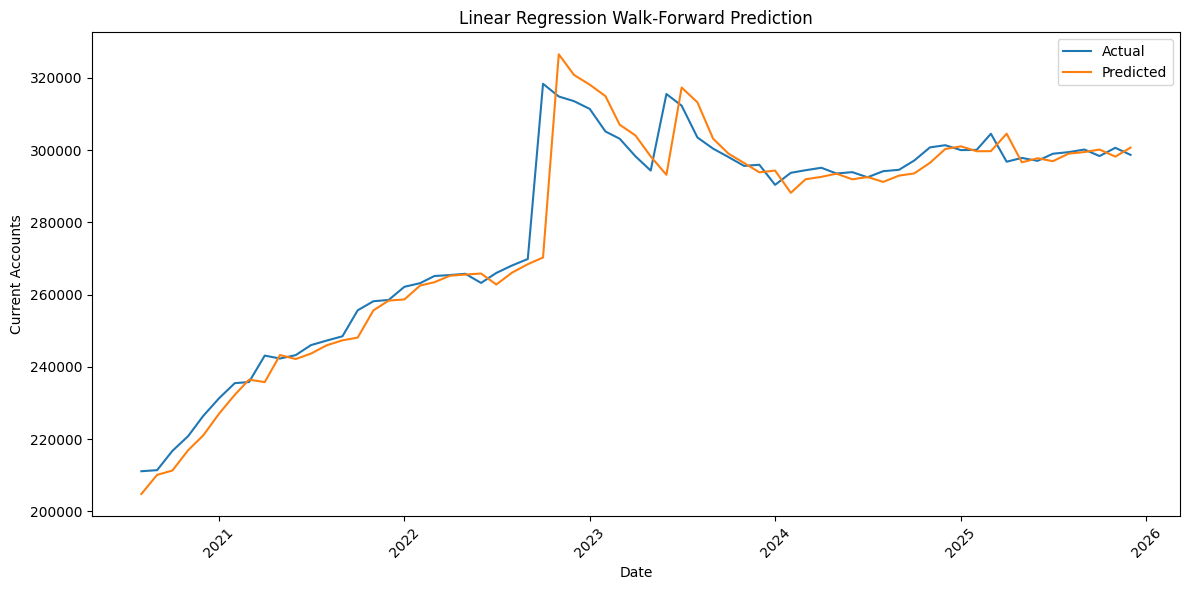

In [82]:
lr_results = pd.DataFrame({
    "Date": lr_dates,
    "Actual": lr_actuals,
    "Predicted": lr_predictions
})

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    lr_results["Date"],
    lr_results["Actual"],
    label="Actual"
)

plt.plot(
    lr_results["Date"],
    lr_results["Predicted"],
    label="Predicted"
)

plt.title(
    "Linear Regression Walk-Forward Prediction"
)

plt.xlabel("Date")
plt.ylabel("Current Accounts")

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

**Linear Regression Residual Plot**

Columns before residual:
['Date', 'Actual', 'Predicted']

Columns after residual:
['Date', 'Actual', 'Predicted', 'Residual']

First 5 residuals:
   Actual      Predicted     Residual
0  211087  204783.030298  6303.969702
1  211384  210085.805565  1298.194435
2  216706  211272.702652  5433.297348
3  220791  216890.323042  3900.676958
4  226428  221033.362764  5394.637236


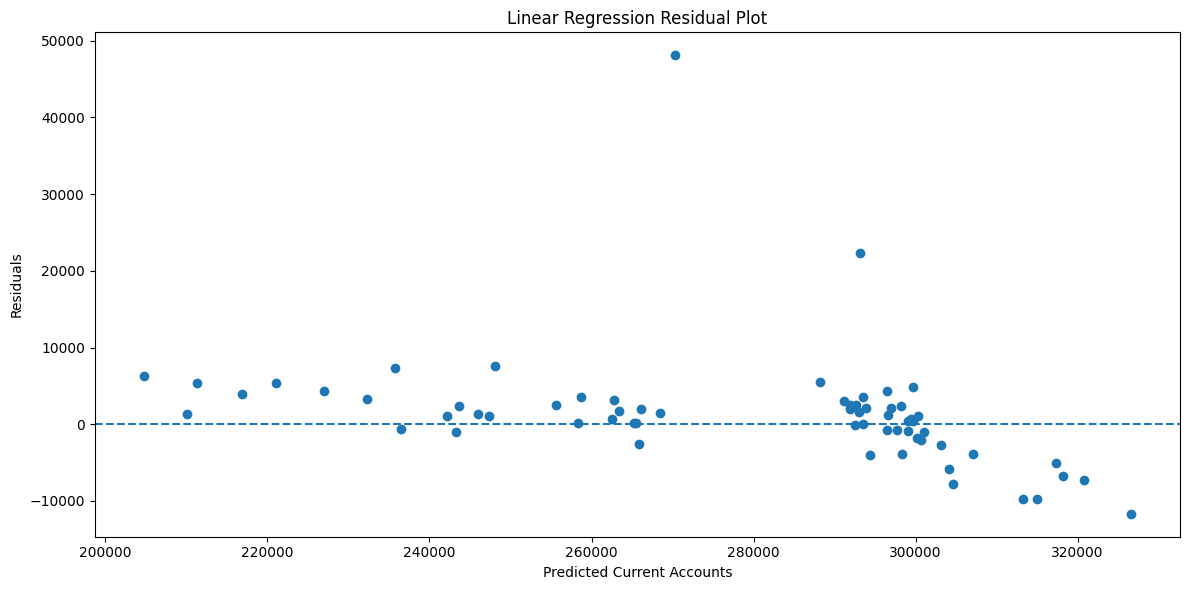

In [83]:


# Create results DataFrame
lr_results = pd.DataFrame({
    "Date": lr_dates,
    "Actual": lr_actuals,
    "Predicted": lr_predictions
})

# Check that the data exists
print("Columns before residual:")
print(lr_results.columns.tolist())

# Calculate residuals
lr_results["Residual"] = (
    lr_results["Actual"] - lr_results["Predicted"]
)

# Check that Residual was created
print("\nColumns after residual:")
print(lr_results.columns.tolist())

print("\nFirst 5 residuals:")
print(lr_results[["Actual", "Predicted", "Residual"]].head())



plt.figure(figsize=(12, 6))

plt.scatter(
    lr_results["Predicted"],
    lr_results["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Linear Regression Residual Plot"
)

plt.xlabel(
    "Predicted Current Accounts"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.show()

**Random Forest Walk-Forward**

In [84]:
for i in range(
    initial_train_size,
    len(df_model)
):

    # Historical training data
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    # Next observation
    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    # -----------------------------
    # Random Forest
    # -----------------------------

    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    prediction = rf_model.predict(
        X_test
    )[0]

    rf_predictions.append(
        prediction
    )

    rf_actuals.append(
        y_test
    )

    rf_dates.append(
        df_model.iloc[i]["Date"]
    )

print(
    "Random Forest walk-forward completed."
)

Random Forest walk-forward completed.


**Random Forest Evaluation**

In [85]:
rf_r2 = r2_score(rf_actuals, rf_predictions)

rf_mae = mean_absolute_error(
    rf_actuals,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        rf_actuals,
        rf_predictions
    )
)

print("RANDOM FOREST")
print("=============")
print("R²   :", round(rf_r2, 4))
print("MAE  :", round(rf_mae, 2))
print("RMSE :", round(rf_rmse, 2))

RANDOM FOREST
R²   : 0.3664
MAE  : 18986.13
RMSE : 23146.93


**Random Forest Feature Importance**

In [86]:

# Get feature names from the actual X dataset
feature_names = X.columns.tolist()

# Get importance from the final RF model
rf_importances = np.asarray(
    rf_model.feature_importances_
).ravel()

# Check lengths
print("Number of features:", len(feature_names))
print("Number of importances:", len(rf_importances))

# Create DataFrame
if len(feature_names) == len(rf_importances):

    rf_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_importances
    })

    rf_importance = rf_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nRandom Forest Feature Importance")
    print(rf_importance)

else:
    print("\nERROR: Feature names and importances have different lengths.")

Number of features: 5
Number of importances: 5

Random Forest Feature Importance
                 Feature  Importance
4  Current_Accounts_Lag1    0.525182
3      Unemployment_Rate    0.262648
0              Bank_Rate    0.113617
1                    CPI    0.064471
2             GDP_Growth    0.034082


**Random Forest Actual vs Predicted**

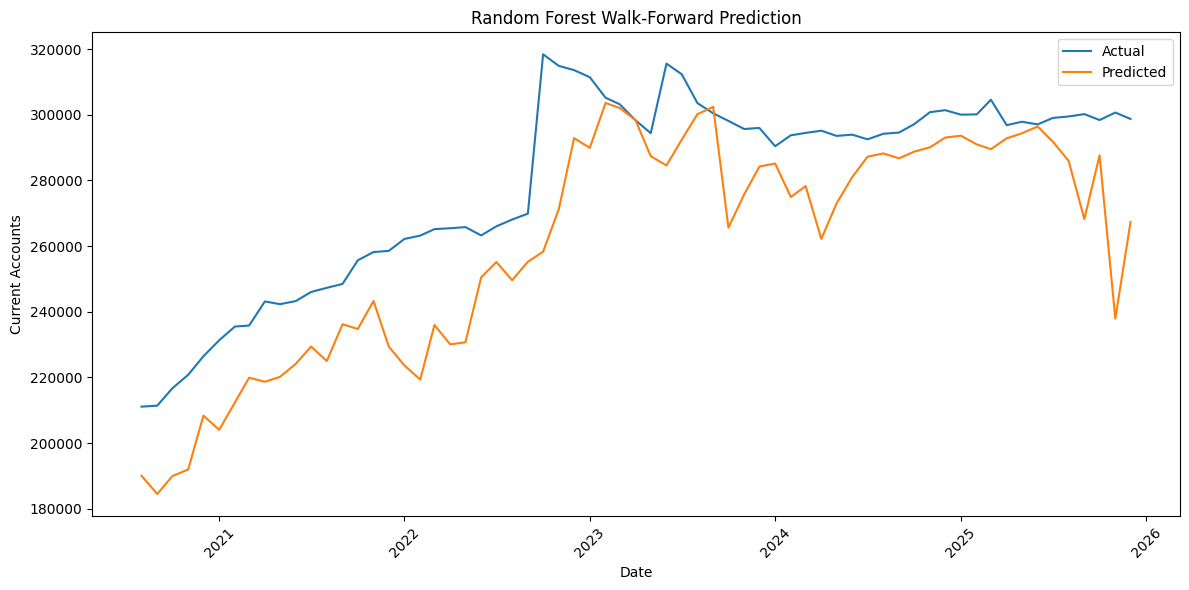

In [87]:
rf_results = pd.DataFrame({
    "Date": rf_dates,
    "Actual": rf_actuals,
    "Predicted": rf_predictions
})

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    rf_results["Date"],
    rf_results["Actual"],
    label="Actual"
)

plt.plot(
    rf_results["Date"],
    rf_results["Predicted"],
    label="Predicted"
)

plt.title(
    "Random Forest Walk-Forward Prediction"
)

plt.xlabel("Date")
plt.ylabel("Current Accounts")

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

**Random Forest Residual Plot**

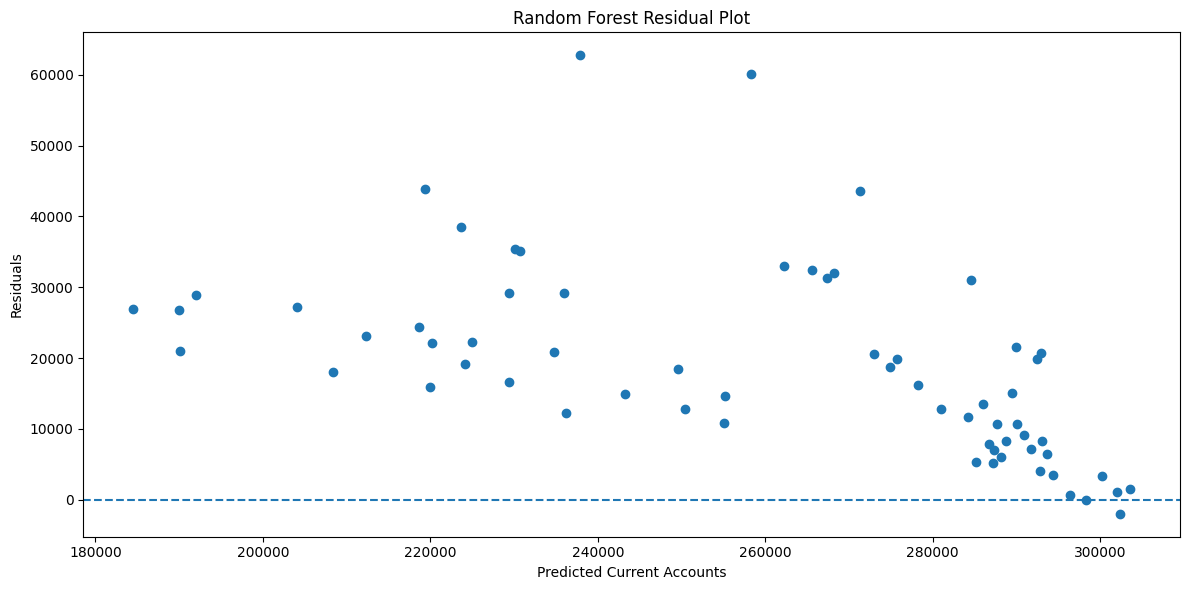

In [88]:

rf_results = pd.DataFrame({
    "Date": rf_dates,
    "Actual": rf_actuals,
    "Predicted": rf_predictions
})

# Calculate residuals
rf_results["Residual"] = (
    rf_results["Actual"] - rf_results["Predicted"]
)

# Residual plot
plt.figure(figsize=(12, 6))

plt.scatter(
    rf_results["Predicted"],
    rf_results["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Random Forest Residual Plot"
)

plt.xlabel(
    "Predicted Current Accounts"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.show()

**XGBoost Walk-Forward**

In [89]:
for i in range(
    initial_train_size,
    len(df_model)
):

    # Historical training data
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    # Next observation
    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    # -----------------------------
    # XGBoost
    # -----------------------------

    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=42
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    prediction = xgb_model.predict(
        X_test
    )[0]

    xgb_predictions.append(
        prediction
    )

    xgb_actuals.append(
        y_test
    )

    xgb_dates.append(
        df_model.iloc[i]["Date"]
    )

print(
    "XGBoost walk-forward completed."
)

XGBoost walk-forward completed.


**XGBoost Evaluation**

In [90]:
xgb_r2 = r2_score(
    xgb_actuals,
    xgb_predictions
)

xgb_mae = mean_absolute_error(
    xgb_actuals,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        xgb_actuals,
        xgb_predictions
    )
)

print("XGBOOST")
print("=======")

print(
    "R²   :",
    round(xgb_r2, 4)
)

print(
    "MAE  :",
    round(xgb_mae, 2)
)

print(
    "RMSE :",
    round(xgb_rmse, 2)
)

XGBOOST
R²   : 0.8273
MAE  : 8117.14
RMSE : 12084.53


**XGBoost Feature Importance**

In [91]:

# Get the actual feature names
feature_names = X.columns.tolist()

# Get feature importance from the final XGBoost model
xgb_importances = np.asarray(
    xgb_model.feature_importances_
).ravel()

# Check lengths
print("Number of features:", len(feature_names))
print("Number of importances:", len(xgb_importances))

# Create DataFrame only if lengths match
if len(feature_names) == len(xgb_importances):

    xgb_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_importances
    })

    xgb_importance = xgb_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nXGBoost Feature Importance")
    print(xgb_importance)

else:
    print("\nERROR: Feature names and importances have different lengths.")

Number of features: 5
Number of importances: 5

XGBoost Feature Importance
                 Feature  Importance
4  Current_Accounts_Lag1    0.642822
3      Unemployment_Rate    0.233933
0              Bank_Rate    0.101921
2             GDP_Growth    0.011958
1                    CPI    0.009365


**XGBoost Actual vs Predicted**

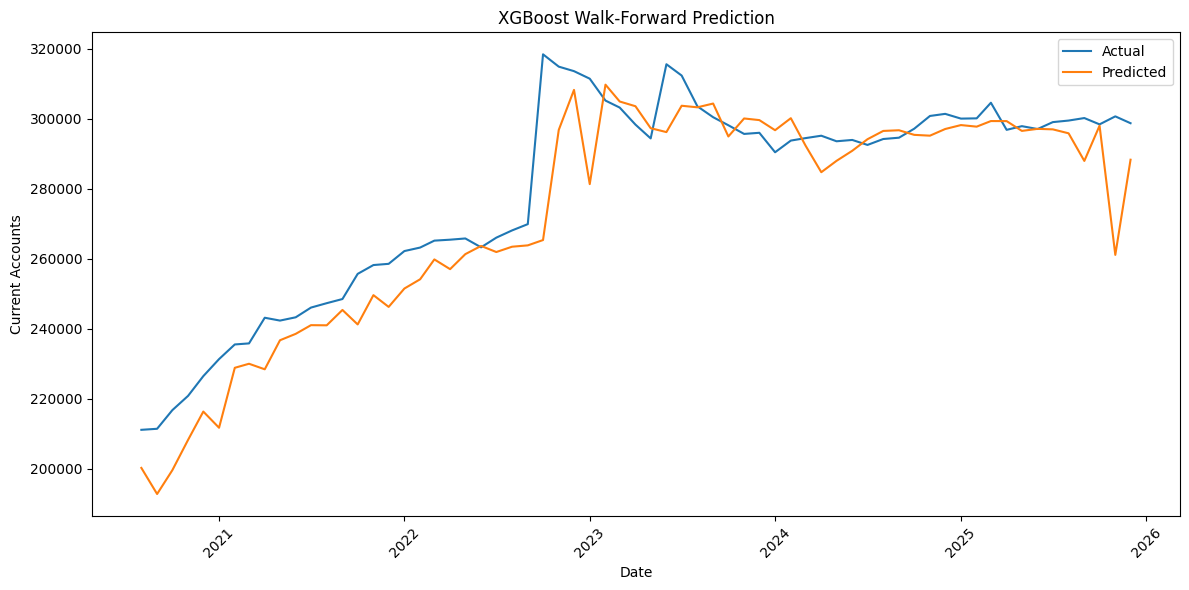

In [92]:
xgb_results = pd.DataFrame({
    "Date": xgb_dates,
    "Actual": xgb_actuals,
    "Predicted": xgb_predictions
})

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    xgb_results["Date"],
    xgb_results["Actual"],
    label="Actual"
)

plt.plot(
    xgb_results["Date"],
    xgb_results["Predicted"],
    label="Predicted"
)

plt.title(
    "XGBoost Walk-Forward Prediction"
)

plt.xlabel("Date")
plt.ylabel("Current Accounts")

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

**XGBoost Residual Plot**

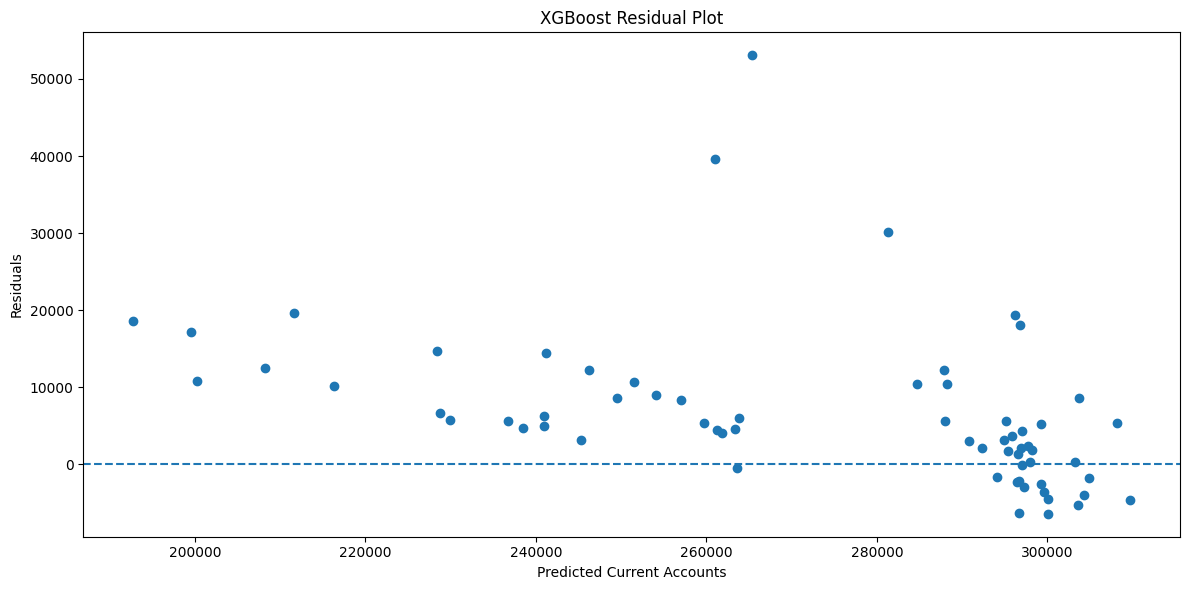

In [93]:

xgb_results = pd.DataFrame({
    "Date": xgb_dates,
    "Actual": xgb_actuals,
    "Predicted": xgb_predictions
})

# Calculate residuals
xgb_results["Residual"] = (
    xgb_results["Actual"] - xgb_results["Predicted"]
)

# Residual plot
plt.figure(figsize=(12, 6))

plt.scatter(
    xgb_results["Predicted"],
    xgb_results["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "XGBoost Residual Plot"
)

plt.xlabel(
    "Predicted Current Accounts"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.show()

**Model Comparison**

In [94]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R²": [
        lr_r2,
        rf_r2,
        xgb_r2
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

comparison = (
    comparison
    .sort_values(
        by="R²",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.929676,4104.515581,7711.753164
1,XGBoost,0.827315,8117.136538,12084.527995
2,Random Forest,0.366449,18986.132285,23146.925995


**Model Comparison Plot**

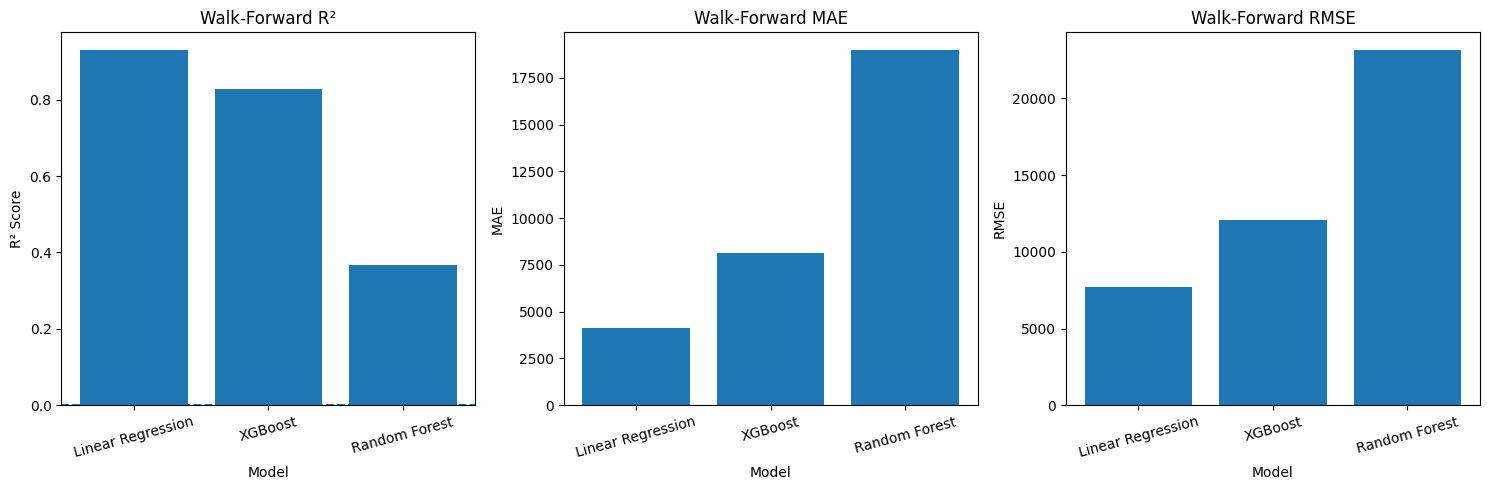

In [95]:
plt.figure(figsize=(15, 5))

# R²
plt.subplot(1, 3, 1)

plt.bar(
    comparison["Model"],
    comparison["R²"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Walk-Forward R²")

plt.xticks(rotation=15)


# MAE
plt.subplot(1, 3, 2)

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Walk-Forward MAE")

plt.xticks(rotation=15)


# RMSE
plt.subplot(1, 3, 3)

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Walk-Forward RMSE")

plt.xticks(rotation=15)


plt.tight_layout()

plt.show()

**Comparison and Best model**

In [96]:
comparison = comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("WALK-FORWARD MODEL COMPARISON")
print("=============================")

display(comparison)

print(
    "\nBest model based on R²:",
    comparison.loc[0, "Model"]
)

WALK-FORWARD MODEL COMPARISON


,Model,R²,MAE,RMSE
0,Linear Regression,0.929676,4104.515581,7711.753164
1,XGBoost,0.827315,8117.136538,12084.527995
2,Random Forest,0.366449,18986.132285,23146.925995



Best model based on R²: Linear Regression


In [97]:
import joblib
import os

os.makedirs(
    "../synthetic_bank/models",
    exist_ok=True
)

In [98]:
joblib.dump(
    final_lr_model,
    "../synthetic_bank/models/current_account_lr.pkl"
)

print("current_account_lr.pkl saved.")

current_account_lr.pkl saved.


In [99]:
joblib.dump(
    final_scaler,
    "../synthetic_bank/models/current_account_scaler.pkl"
)

print("current_account_scaler.pkl saved.")

current_account_scaler.pkl saved.


In [100]:
current_account_features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Current_Accounts_Lag1"
]

joblib.dump(
    current_account_features,
    "../synthetic_bank/models/current_account_features.pkl"
)

print("current_account_features.pkl saved.")

current_account_features.pkl saved.
